# 绘图与可视化

制作信息丰富的可视化图表是数据分析中最重要的任务之一。这些可视化图表既可以用于数据探索过程，例如帮助识别异常值或确定所需的数据处理方式；也可以作为构建数据模型的参考依据。对于某些人来说，制作可用于网页的交互式可视化图表才是最终目标。Python提供了许多用于制作静态或动态可视化图表的第三方库，但我主要会重点介绍matplotlib以及基于matplotlib开发的各类库。

matplotlib是一个用于创建适合发表的图表和图像的桌面绘图工具包。该项目由John Hunter于2002年发起，旨在为Python提供类似MATLAB的绘图功能。matplotlib与IPython社区紧密合作，共同简化了通过IPython shell（以及现在的Jupyter笔记本）进行交互式绘图的操作。matplotlib支持在各种操作系统上运行，并能够将生成的可视化图像导出为常见的矢量图形和光栅图形格式（如PDF、SVG、JPG、PNG、BMP、GIF等）。除了少数图表外，本书中的所有图形都是使用matplotlib制作的。

随着时间的推移，matplotlib催生了许多用于数据可视化的插件工具包，这些工具包都基于matplotlib来进行数据绘图。其中之一就是seaborn，我们将在本章后面详细介绍它。

要查看本章中的代码示例，最简单的方法就是在 Jupyter 笔记本中输出相应的图表。为此，请在 Jupyter 笔记本中执行以下命令：

In [2]:
%matplotlib inline

> 自本书于2012年首次出版以来，出现了许多新的数据可视化库。其中一些库（如Bokeh和Altair）充分利用了现代网络技术，能够生成与Jupyter笔记本完美兼容的交互式可视化效果。在本书中，我决定仅使用matplotlib来讲解数据可视化的基本原理，因为pandas与matplotlib的集成度非常高。通过学习本章的内容，你也可以掌握如何使用其他数据可视化库。

## matplotlib API入门指南

在使用 matplotlib 时，我们采用以下导入代码的规范：

In [3]:
import matplotlib.pyplot as plt

在 Jupyter 中运行 `%matplotlib notebook`（或在 IPython 中直接使用 `%matplotlib`）后，我们可以尝试绘制一个简单的图表。如果设置正确，应该会显示出一个类似“简单折线图”的图形。

In [4]:
import numpy as np

data = np.arange(10)
data

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

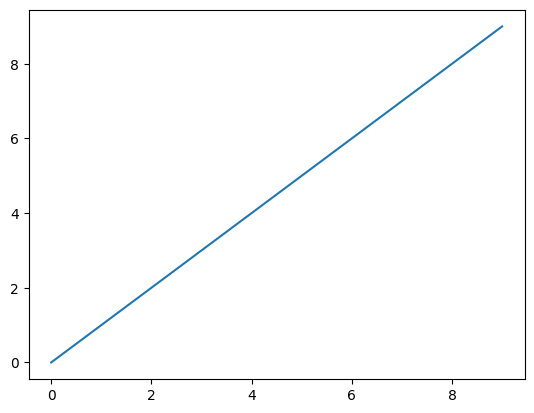

In [5]:
plt.plot(data)

虽然像 seaborn和pandas这样的库提供了内置的绘图功能，可以处理绘制图表时所需的许多繁琐细节，但如果你希望对这些功能进行更深入的定制，就需要学习一下matplotlib的API了。

> 这本书的篇幅有限，无法全面介绍matplotlib的所有功能及其使用方法。不过，它应该足以帮助你掌握基本的使用技巧，从而开始使用matplotlib进行数据可视化。如果你想学习matplotlib的更高级功能，matplotlib的示例代码库及官方文档是最佳的学习资源。

### 图表与子图

在matplotlib中，所有的绘图内容都存储在Figure对象中。你可以使用`plt.figure()`来创建一个新的Figure对象。

In [6]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

在 IPython 中，如果你先运行 `%matplotlib` 命令来设置 matplotlib 的集成功能，那么会弹出一个空白的绘图窗口；而在 Jupyter 中，除非我们再执行一些命令，否则屏幕上什么也不会显示出来。

`plt.figure`提供了许多选项；其中，`figsize`这个选项可以确保绘制的图形在保存到磁盘时具有固定的尺寸和宽高比。

你无法用一个空图形来构建图表；你必须使用 `add_subplot` 函数来创建一个或多个子图，才能完成图表的绘制。

In [7]:
ax1 = fig.add_subplot(2, 2, 1)  # 行，列，索引

这意味着该图应该由2×2个子图组成（总共四个子图），而我们选择的是这四个子图中的第一个子图（编号为1）。如果你再创建另外两个子图，最终得到的可视化效果将是一个包含三个子图的空matplotlib图形。

In [8]:
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

> 使用 Jupyter 笔记本时有一个需要注意的地方：每个单元格被执行后，其中的图表都会被重置，因此所有与绘图相关的命令都必须放在同一个单元格中。

在这里，我们将所有这些命令都在同一个单元格中执行。

<Axes: >

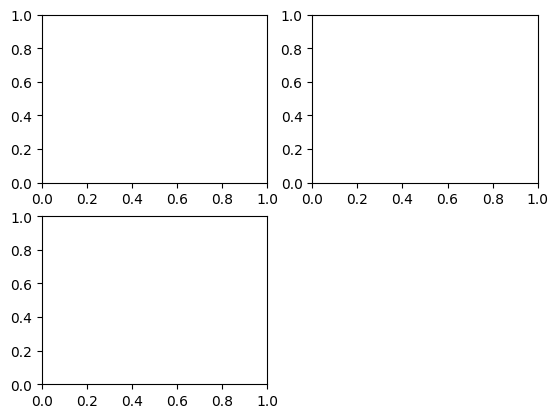

In [9]:
fig = plt.figure()
fig.add_subplot(2, 2, 1)
fig.add_subplot(2, 2, 2)
fig.add_subplot(2, 2, 3)

这些绘图轴对象提供了多种用于生成不同类型图表的方法。相比之下，使用这些轴对象提供的方法要比直接使用像 `plt.plot` 这样的高级绘图函数更合适。例如，我们可以使用 `plot` 方法来绘制折线图（详见“单个图表的可视化展示”部分）。

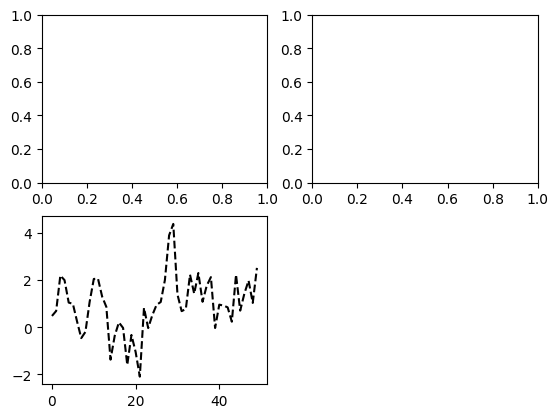

In [10]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(np.random.standard_normal(50).cumsum(), color='black', linestyle='dashed', label='dashed')

运行该程序时，你可能会看到类似“<matplotlib.lines.Line2D at …>”这样的输出信息。matplotlib会返回一些用于引用刚刚被添加到的绘图组件的对象。大多数情况下，你可以忽略这些输出信息；或者你也可以在每行的末尾加上分号来抑制这些输出信息的显示。

这些额外的选项用于指示 matplotlib 绘制一条黑色的虚线。在这里，`fig.add_subplot` 返回的是 `AxesSubplot` 对象，你可以通过调用这些对象的实例方法，在其他未使用的子图上直接进行绘图操作（详见“添加额外图表后的数据可视化”部分）。

In [11]:
def plot(rows, cols):
    fig = plt.figure()
    subplots = []
    for i in range(1, rows * cols + 1):
        ax = fig.add_subplot(rows, cols, i)
        subplots.append(ax)
    return subplots

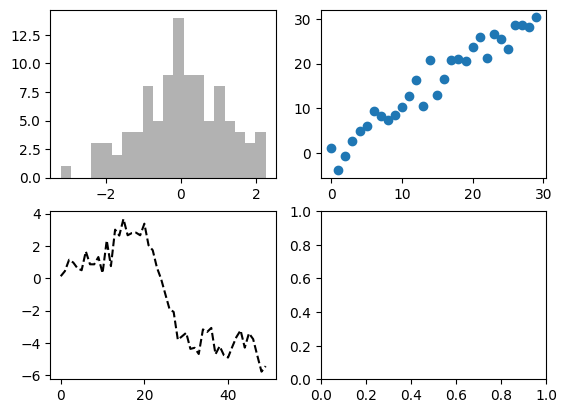

In [12]:
axs = plot(2, 2)
axs[0].hist(np.random.standard_normal(100), bins=20, color='k', alpha=0.3)
axs[1].scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))
axs[2].plot(np.random.standard_normal(50).cumsum(), 'k--')

`alpha=0.3`这一样式设置用于控制叠加图形的透明度。

为了更方便地创建子图网格，matplotlib提供了`plt.subplots`方法。该方法会创建一个新的图形，并返回一个包含所有创建的子图对象的NumPy数组。

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

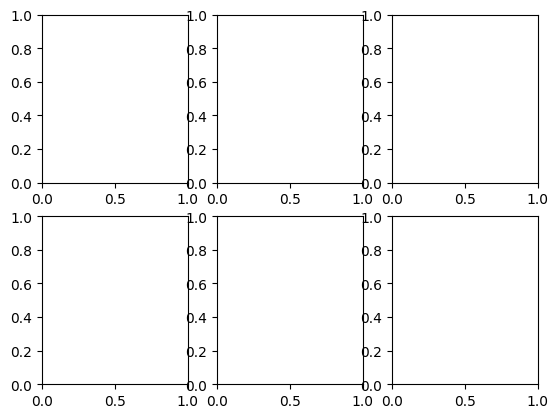

In [13]:
fig, axes = plt.subplots(2, 3)
axes

此时，可以像操作二维数组一样来访问 axes 数组；例如，axes[0, 1] 表示位于顶部行中间的子图。此外，还可以使用 sharex 和 sharey 分别指定子图应共享相同的 x 轴或 y 轴。在需要比较处于相同尺度下的数据时，这种方法非常有用；否则，matplotlib 会自动为每个子图设置不同的坐标范围。有关更多详细信息，请参下表：
| 参数 | 描述 |
|------|-----|
| nrows | 子图的行数 |
| ncols | 子图的列数 |
| sharex | 所有子图应使用相同的x轴刻度；调整x轴的显示范围会影响到所有子图。|
| sharey | 所有子图应使用相同的y轴刻度；调整ylim参数会影响到所有子图。|
| subplot_kw | 用于创建每个子图的 subplot 函数调用中传递的关键词字典 |
| **fig_kw | 在绘制图表时，还可以使用其他关键字来定义子图，例如：`plt.subplots(2, 2, figsize=(8, 6))`。|

#### 调整子图之间的间距

默认情况下，matplotlib会在子图的外围以及子图之间的间距处设置一定的填充区域。这些间距都是根据图表的高度和宽度来确定的；因此，无论你是通过编程方式还是通过图形用户界面手动调整图表的大小，图表都会自动进行相应的调整。你可以使用 Figure 对象上的 subplot_adjust 方法来更改子图之间的间距。

`subplots_adjust(left=None, bottom=None, right=None, top=None,
                wspace=None, hspace=None)`

`wspace`和`hspace`分别用于控制子图之间的间距所占图形宽度和图形高度的比例。下面是一个可以在Jupyter中运行的小示例：在这个示例中，我将子图之间的间距设置为了零（详见“无子图间距的数据可视化”部分）。

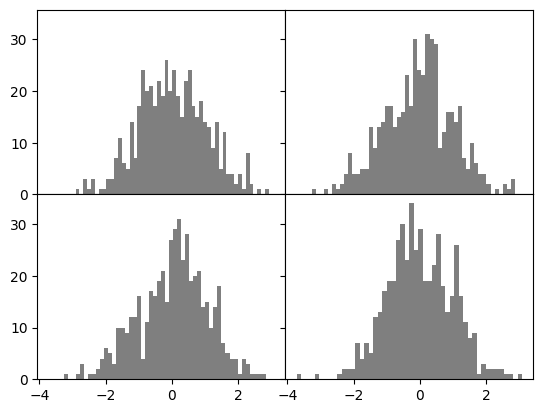

In [14]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.standard_normal(500), bins=50, color='k', alpha=0.5) 
fig.subplots_adjust(wspace=0, hspace=0)

你可能会发现轴标签相互重叠了。matplotlib并不会自动检查标签是否重叠，因此在这种情况下，你需要自行调整标签的位置，具体方法就是明确指定刻度位置及刻度标签的内容（我们将在后面的“刻度、标签与图例”章节中详细介绍如何操作）。

### 颜色、标记符号及线条样式

matplotlib的折线图函数可以接受x坐标和y坐标的数组，以及可选的颜色设置选项。例如，如果你想绘制x与y的关系图，并使用绿色虚线来表示数据，就可以这样操作：
```python
ax.plot(x, y, linestyle="--", color="green")`
```
对于常用的颜色，提供了相应的名称供您选择；不过，您也可以通过指定颜色的十六进制代码来使用光谱中的任意颜色（例如“#CECECE”）。要查看支持的各种线型，可以查阅 `plt.plot` 的文档字符串（在 IPython 或 Jupyter 中输入 `plt.plot?` 即可查看）。更详细的参考信息可以在在线文档中找到。

折线图还可以添加标记来突出显示实际的数据点。由于matplotlib的plot函数会生成连续的折线图，并在数据点之间进行插值处理，因此有时很难准确判断数据点的具体位置。此时，可以通过添加标记来更清晰地显示数据点（详见“带标记的折线图”示例）。

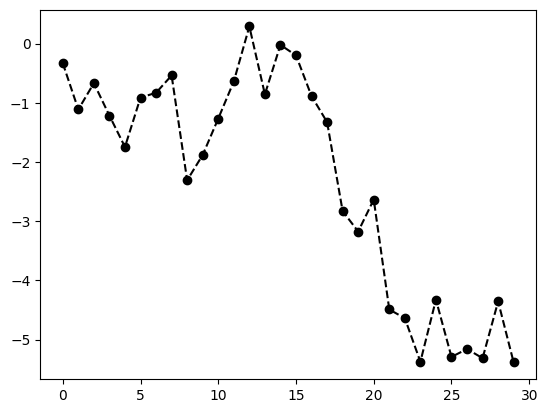

In [15]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(np.random.standard_normal(30).cumsum(), color='black', linestyle='--', marker='o')

对于折线图来说，默认情况下，后续数据点会通过线性插值的方式连接在一起。您可以通过设置 `drawstyle` 选项来改变这一默认设置（详见“使用不同 `drawstyle` 选项绘制的折线图”）。

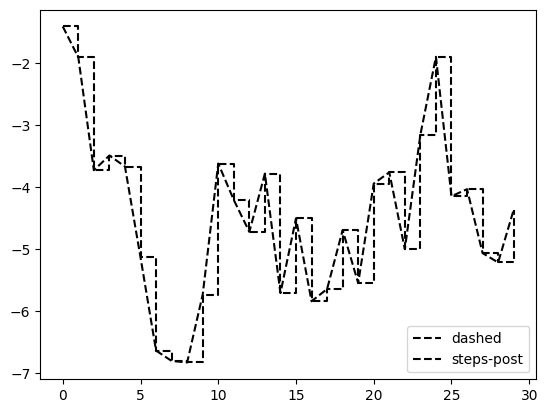

In [16]:
fig = plt.figure()
ax = fig.add_subplot()
data = np.random.standard_normal(30).cumsum()
ax.plot(data, 'k--', label='dashed')
ax.plot(data, 'k--', label='steps-post', drawstyle='steps-post')
ax.legend()

在这里，由于我们已经将标签参数传递给了绘图函数，因此可以使用 `ax.legend` 来为图表添加图例，从而识别每条曲线。关于图例的更多内容，我会在“刻度、标签与图例”这一章节中详细说明。

> 无论在绘制数据时是否指定了标签选项，都必须调用 ax.legend 函数来生成图例。

### 刻度线、标签及图例

大多数用于美化图形的元素都可以通过 matplotlib 的轴对象提供的方法来设置。例如 `xlim`、`xticks` 和 `xticklabels` 等方法分别用于控制图形的显示范围、刻度位置以及刻度标签的内容。这些方法可以使用两种方式来调用：
- 如果不带任何参数调用该函数，它将返回当前的参数值；例如，`ax.xlim()`会返回当前的x轴绘图范围。
- 通过传递参数来设置相应的值；例如，`ax.xlim([0, 10])`表示将x轴的显示范围设置为`0`到`10`。

所有这些方法都是作用于当前处于活动状态或最新创建的 `AxesSubplot` 对象的。实际上，每种方法都对应于 `subplot` 对象本身提供的两个方法；以 `xlim` 为例，这两个方法分别是 `ax.get_xlim` 和 `ax.set_xlim`。

#### 设置标题、轴标签、刻度线以及刻度标签的内容

为了说明如何自定义坐标轴，我将绘制一个简单的随机游走过程图来演示如何设置 `x` 轴的刻度及标签（使用默认的标签设置）。

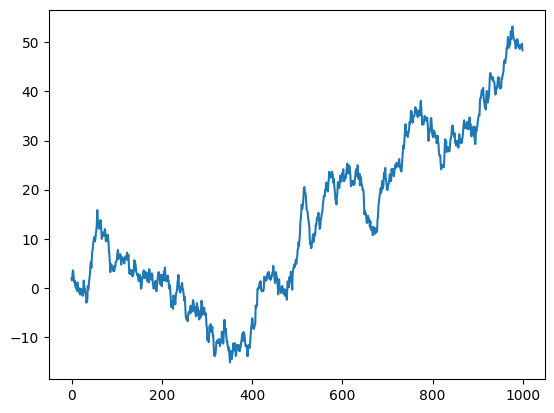

In [17]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum())

要更改x轴上的刻度，最简单的方法是使用`set_xticks`和`set_xticklabels`。`set_xticks`用于指定matplotlib应在数据范围的哪些位置上显示刻度；默认情况下，这些位置也会被同时用作刻度标签。不过，我们也可以使用`set_xticklabels`来为刻度设置其他形式的标签。

Text(0.5, 1.0, 'My First Matplotlib Plot')

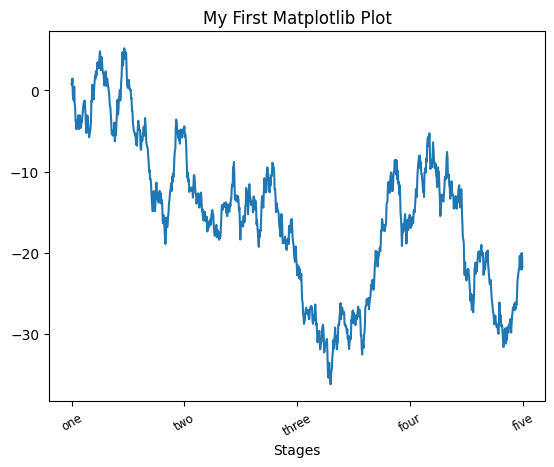

In [18]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum())
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'],
                            rotation=30, fontsize='small')
ax.set_xlabel("Stages")
ax.set_title("My First Matplotlib Plot")

`rotation`选项可将x轴上的刻度标签设置为以30度为间隔进行旋转。此外，`set_xlabel`用于为x轴设置名称，而`set_title`则用于设置子图的标题（有关如何为图表设置自定义x轴刻度标签的示例，请参见“简单图表”部分）。

修改y轴的步骤与修改x轴的步骤相同，只需在这个例子中将x替换为y即可。Axes类提供了一个set方法，可以批量设置图表的属性。根据前面的例子，我们也可以这样写：

In [19]:
ax.set(title="My First Matplotlib Plot", xlabel="Stages")

[Text(0.5, 1.0, 'My First Matplotlib Plot'),
 Text(0.5, 24.000000000000007, 'Stages')]

#### 添加图例

图例也是识别情节要素的重要依据。添加图例的方法有几种：最简单的方法是在绘制每个情节元素时直接为其指定相应的标签，完成这些操作后，你可以调用 `ax.legend()` 来自动生成图例。这样生成的图表会是一个包含三条线条及图例的简单图表:

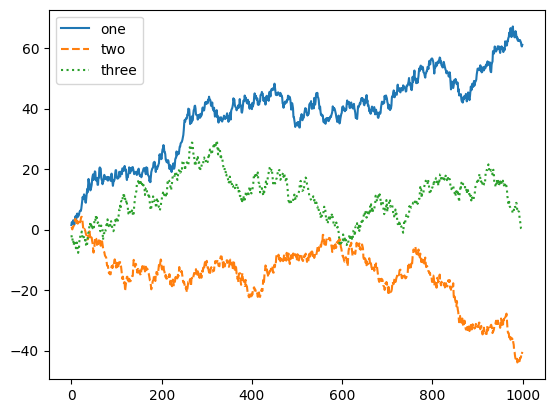

In [20]:
fig, ax = plt.subplots()
ax.plot(np.random.randn(1000).cumsum(), label='one')
ax.plot(np.random.randn(1000).cumsum(), label='two', linestyle='--')
ax.plot(np.random.randn(1000).cumsum(), label='three', linestyle=':')
ax.legend()

对于 `loc` 参数，`legend` 方法还提供了其他几种可选的设置方式。更多详细信息，请参阅文档说明。

`loc`选项用于指定matplotlib应将图例放置在哪里。默认设置为“best”，该选项会自动选择最不会妨碍图表显示的位置。如果希望将某个或多个元素从图例中排除，可以不为其设置标签，或者将标签设置为“\_nolegend\_”。

### ​​子图的标注与绘制​​

除了标准类型的图表外，您还可以自行添加图表注释，这些注释可以包含文本、箭头或其他形状。您可以使用“text”、“arrow”以及“annotate”等函数来添加注释和文本。使用“text”函数时，可以在图表的指定坐标（x, y）处显示文本，并且还可以自定义文本的显示样式。

Text(0.5, 0.5, 'Hello World')

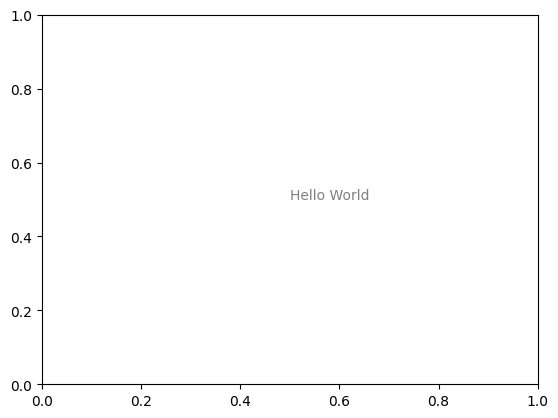

In [21]:
fig, ax = plt.subplots()
ax.text(0.5, 0.5, "Hello World",
        fontsize=10, color='gray')


注释中可以同时添加文本和箭头，并对它们的位置进行合理安排。以绘制2007年以来标准普尔500指数的收盘价格为例（数据来自Yahoo! Finance），同时可以在图表上标注2008–2009年金融危机期间的一些重要日期。你可以在Jupyter笔记本的某个单元格中运行这段代码。具体结果请参见“2008–2009年金融危机期间的重要日期”部分。

Text(0.5, 1.0, 'Important dates in the 2008-2009 financial crisis')

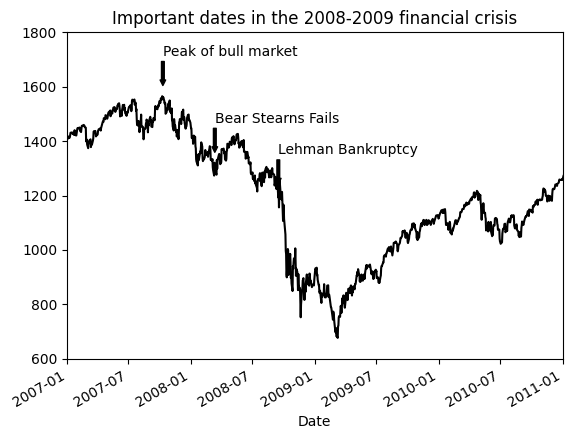

In [22]:
'''
Author: lengyhua lengyhua@163.com
Date: 2025-11-11 22:33:18
LastEditors: lengyhua lengyhua@163.com
LastEditTime: 2025-11-14 22:25:16
FilePath: /python-for-data-analysis/Chapter9 绘图与可视化.ipynb
Description: 这是默认设置,请设置`customMade`, 打开koroFileHeader查看配置 进行设置: https://github.com/OBKoro1/koro1FileHeader/wiki/%E9%85%8D%E7%BD%AE
'''
from datetime import datetime
import pandas as pd
fig, ax = plt.subplots()
data = pd.read_csv('examples/spx.csv', index_col=0, parse_dates=True)
spx = data['SPX']
spx.plot(ax=ax, style='k-')

crisis_data = [
    (datetime(2007, 10, 11), 'Peak of bull market'),
    (datetime(2008, 3, 12), 'Bear Stearns Fails'),
    (datetime(2008, 9, 15), 'Lehman Bankruptcy')
]
for date, label in crisis_data:
    ax.annotate(label,
                xy=(date, spx.asof(date) + 50),
                xytext=(date, float(spx.asof(date)) + 200),
                arrowprops=dict(facecolor='black', headwidth=4, width=2,
                                headlength=4),
                horizontalalignment='left',
                verticalalignment='top')
ax.set_xlim(['1/1/2007', '1/1/2011'])
ax.set_ylim([600, 1800])
ax.set_title("Important dates in the 2008-2009 financial crisis")

在这个图表中，有几点值得特别注意：`axannotate`方法可以用来在指定的x坐标和y坐标处添加标签；我们使用`set_xlim`和`setylim`方法来手动设置图表的显示范围，而不是使用matplotlib的默认设置；最后，`ax.set_title`用于为图表添加标题。

你可以在matplotlib的在线图库中找到更多注释示例，从而从中学习相关知识。

绘制各种形状时需要更加细心一些。matplotlib提供了用于表示常见形状的类，这些类被称为“补丁对象”。其中一些补丁对象，如矩形和圆形，属于`matplotlib.pyplot`模块；而所有这些补丁对象则都包含在`matplotlib.patches`模块中。

要向图表中添加形状，可以先创建相应的“补丁对象”，然后通过将其传递给 `ax.add_patch` 方法将其添加到子图中（详见“由三个不同补丁组成的数据可视化示例”）。

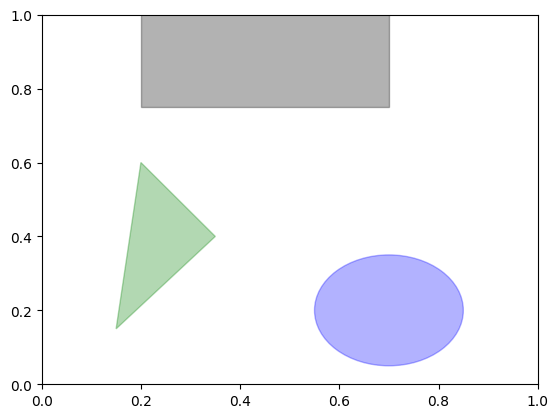

In [23]:
import matplotlib.patches as patches

fig, ax = plt.subplots()

rect = patches.Rectangle((0.2, 0.75), 0.5, 0.3, color='black', alpha=0.3)
circ = patches.Circle((0.7, 0.2), 0.15, color='blue', alpha=0.3)
poly = patches.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]], color='green', alpha=0.3)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(poly)

如果你仔细观察许多常见的图表类型的实现方式，就会发现它们都是由各种小块数据组成的。

### 保存到文件

你可以使用图形对象的 `savefig` 方法将当前显示的图形保存到文件中。例如，如果你想将图形的 SVG 格式版本保存下来，只需输入以下命令即可：

```python
plt.savefig('figpath.svg')
```

文件类型是根据其扩展名来确定的。因此，如果你使用的是.pdf扩展名，那么生成的文件自然就是PDF格式了。在发布图形时，我经常使用的一个重要参数是“dpi”——它用于控制图像的每英寸点数，从而影响图像的分辨率。要想获得与400 DPI分辨率的PNG图像效果相同的图形，你需要按照相应的设置来进行处理。

```python
fig.savefig("figpath.png", dpi=400)
```


**fig.savefig选项：**
| 参数 | 说明 |
| :--- | :--- |
| fname | 包含文件路径或类似Python文件的对象的字符串。图形的格式会根据文件扩展名来确定（例如，.pdf表示PDF格式，.png表示PNG格式）。 |
| dpi | 图像的分辨率以每英寸点数来表示。在 IPython 中，默认值为 100 点/英寸；在 Jupyter 中，默认值为 72 点/英寸，但用户可以对其进行自定义设置。 |
| facecolor,edgecolor | 子图之外的图形背景颜色，默认为“w”（白色）。 |
| format | 图像的格式。如果未指定，则根据文件扩展名来确定。 |

### matplotlib配置

matplotlib自带的颜色方案及默认设置主要是为便于图表的出版而设计的。幸运的是，几乎所有的默认设置都可以通过全局参数进行自定义，这些参数可以用来控制图表的尺寸、子图之间的间距、颜色、字体大小、网格样式等。在Python中，可以通过`rc`方法以编程方式修改这些配置。例如，如果想将图表的默认尺寸设置为10×10，可以这样操作：

```python
plt.rc('figure', figsize=(10, 10))
```

当前所有的配置设置都存储在 `plt.rcParams` 字典中，可以通过调用 `plt.rcdefaults()` 函数将它们恢复为默认值。

传递给 `rc` 的第一个参数是你希望自定义的组件，例如 “figure”、“axes”、“xtick”、“ytick”、“grid”、“legend” 等。其后可以接着列出一系列关键字参数，用于指定新的设置值。在程序中设置这些选项的一个便捷方法是使用字典来表示这些参数。

```python
plt.rc("font", family="monospace", weight="bold", size=14)
```
为了实现更详细的自定义设置，并查看所有可用的选项，matplotlib提供了一个名为matplotlibrc的配置文件，该文件位于matplotlib/mpl-data目录中。如果你对这个文件进行自定义修改，然后将其保存到你的主目录下，并将其文件名改为.matplotlibrc，那么每次使用matplotlib时，这个自定义配置都会被自动加载。

正如我们将在下一节中看到的那样，seaborn包提供了多种内置的绘图主题或样式，这些主题/样式实际上都是通过使用matplotlib的配置系统来实现的。


## 使用 pandas 和 seaborn 进行数据绘图

matplotlib其实是一个相当底层的绘图工具。用户需要通过其基本组件来构建图表：数据展示方式（例如折线图、条形图、箱形图、散点图、等高线图等）、图例、标题、刻度标签以及其他注释等。

在pandas中，我们可以拥有多列数据，同时还会有一些行标签和列标签。pandas本身提供了许多内置方法，可以方便地从DataFrame和Series对象中生成可视化图表。另一个常用的可视化工具是seaborn——它是一个基于matplotlib构建的高级统计图形库，能够简化多种常见可视化图形的制作过程。

### 折线图

Series和DataFrame都具备“plot”属性，可用于生成一些基本的图表类型。默认情况下，使用plot()函数可以生成折线图（详见“简单Series图表的生成”）。

<Axes: >

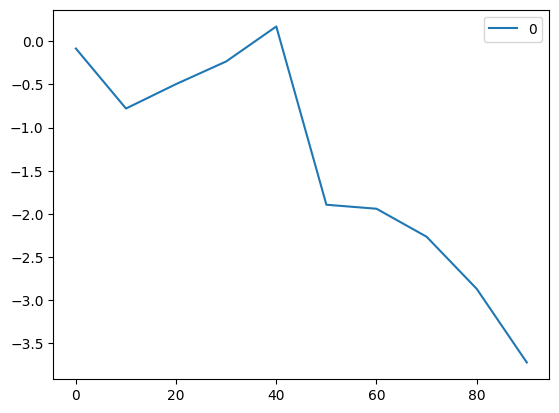

In [24]:
s = pd.DataFrame(np.random.standard_normal(10).cumsum(), index=np.arange(0,100,10))
s.plot()

Series对象的索引会被传递给matplotlib，用于在x轴上绘制数据；不过，你也可以通过设置`use_index=False`来禁用这一功能。x轴的刻度值及显示范围可以通过`xticks`和`xlim`选项进行调整，y轴的相应设置则通过`yticks`和`ylim`选项完成。有关各种绘图选项的详细信息，请参见下表。在本节中，我会对其中一些选项进行进一步说明，其余的则留给你自己去探索。

**Series.plot方法参数**

| 参数 | 描述 |
| --- | --- |
| label | 用于图例的标签 |
| ax | 用于绘图的matplotlib subplot对象；如果未传递任何参数，将使用当前激活的matplotlib subplot对象进行绘图。|
| style | 用于传递给 matplotlib 的样式字符串，例如 “ko--”。|
| alpha | 透明度，范围从0到1。 |
| kind | 绘图类型，可以是“line”、“bar”、“barh”、“kde”、“density”、“area”、“pie”；默认是“line” |
| figsize | 要创建的图形对象的大小 |
| logx | 若需要在x轴上使用对数刻度，则传递True；若需要使用允许负数值的对称对数刻度，则传递“sym”。 |
| logy | 若需要在y轴上使用对数刻度，则传递True；若需要使用允许负数值的对称对数刻度，则传递“sym”。 |
| title | 图形标题 |
| use_index | 若要使用索引作为x轴，则传递True。 |
| rot | x轴标签的旋转角度(0到360) |
| xticks | x轴标签的列表 |
| yticks | y轴标签的列表 |
| grid | 若要显示网格，则传递True |
| xlim | x轴的刻度范围 |
| ylim | y轴的刻度范围 |
| legend | 若要显示图例，则传递True |

Pandas的大部分绘图方法都允许使用一个可选的`ax`参数，该参数可以是一个matplotlib的`subplot`对象。这样一来，你就可以更灵活地在网格布局中安排子图的位置了。

DataFrame的plot方法会将其每一列分别以不同的线条形式显示在同一个子图中，并会自动生成图例（详见“简单的DataFrame图表绘制方法”）。

<Axes: >

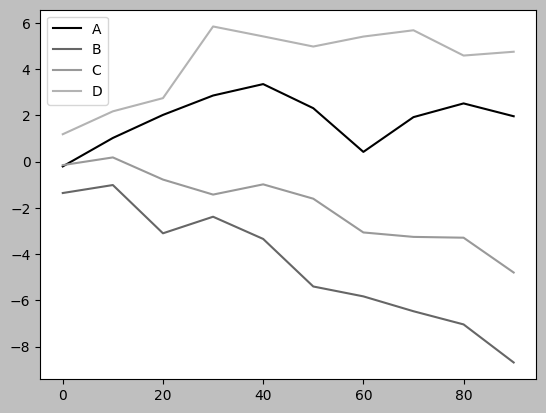

In [25]:
df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0),
                  columns=['A', 'B', 'C', 'D'],
                  index=np.arange(0, 100, 10))
plt.style.use('grayscale')
df.plot()

> 在这里，我使用了 `plt.style.use('grayscale')` 来切换为更适合黑白印刷的配色方案，因为有些读者可能无法看清彩色图表的内容。

`plot`属性包含了一系列适用于不同类型图表的方法。例如，`df.plot()`实际上等同于`df.plot.line()`。接下来，我们将逐一了解这些方法。

> 用于绘图的额外关键字参数会直接传递给相应的 matplotlib 绘图函数，因此你可以通过进一步了解 matplotlib 的 API 来对这些图表进行更详细的自定义设置。

DataFrame提供了多种选项，可以灵活地处理各列的数据：例如，可以选择将所有列绘制在同一个子图中，也可以分别将它们绘制在不同的子图中。更多相关信息请参见下表。

**DataFrame.plot()参数**
| 参数 | 描述 |
| --- | --- |
| subplots | 指定绘图时是否创建多个子图 |
| layout | 创建子图的布局 |
| sharex | 指定绘图时是否共享X轴 |
| sharey | 创建子图时是否共享Y轴 |
| legend | 创建子图时是否显示图例 |
| sort_columns | 指定绘图时是否对列进行排序 |

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)

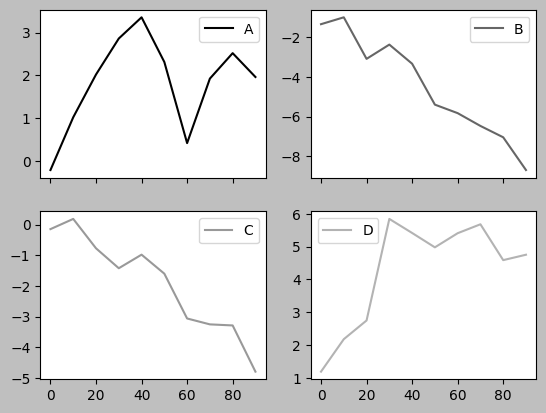

In [26]:
df.plot(subplots=True, layout=(2,2))

### 条形图


`plot.bar()`用于绘制垂直条形图，而`plot.barh()`则用于绘制水平条形图。在这种情况下，Series或DataFrame的索引将分别被用作条形图的x轴或y轴刻度（详见“水平条形图与垂直条形图”相关内容）。


<Axes: >

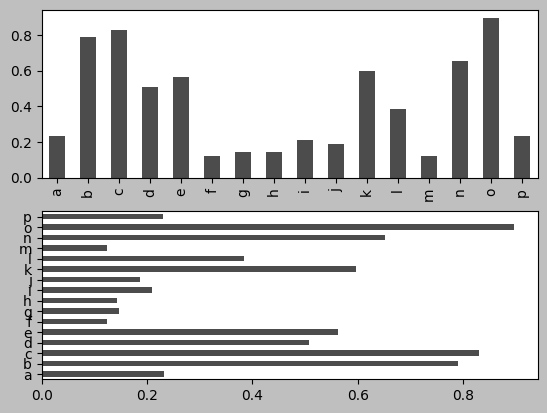

In [36]:
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.uniform(size=16), index=list('abcdefghijklmnop'))
data.plot(ax=axes[0], kind='bar', color='k', alpha=0.7)
data.plot(ax=axes[1], kind='barh', color='k', alpha=0.7)

使用 DataFrame 时，条形图会将每行中的数据按照不同的数值分别以条形图的形式显示出来，这些条形图会并排排列。详见“DataFrame 条形图”。

In [38]:
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
                  index=['one', 'two', 'three', 'four', 'five', 'six'],
                  columns=pd.Index(['A', 'B', 'C', 'D'], name='Genus'))
df

Genus,A,B,C,D
one,0.907656,0.051296,0.506555,0.203013
two,0.456149,0.021063,0.847619,0.262166
three,0.283812,0.171687,0.375985,0.048110
four,0.273556,0.255393,0.246671,0.730451
five,0.860886,0.223254,0.965249,0.098272
six,0.608693,0.651121,0.636417,0.127040


<Axes: >

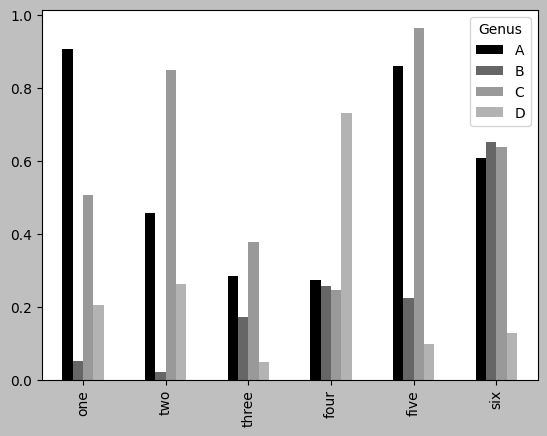

In [39]:
df.plot.bar()

请注意，数据框列名“Genus”被用来作为图例的标题。

我们可以通过设置参数 stacked=True 来从 DataFrame 中生成堆叠条形图，这样每行中的数据就会被水平堆叠在一起（详见“DataFrame 堆叠条形图”示例）。

<Axes: >

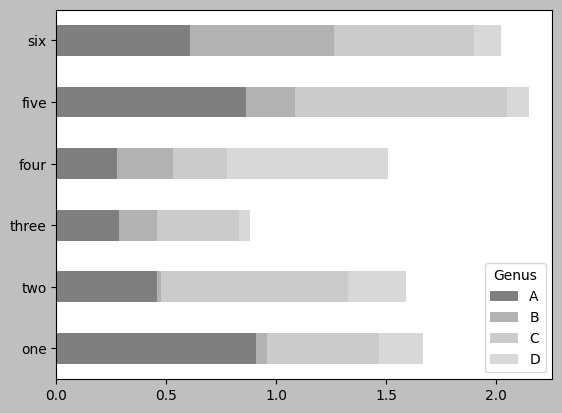

In [40]:
df.plot.barh(stacked=True, alpha=0.5)

> 一个制作条形图的有效方法是通过使用 `value_counts()` 函数来统计数据序列中各数值出现的频率，然后再使用 `plot.bar()` 函数将这些频率数据可视化。具体步骤如下：`s.value_counts().plot.bar()`。

让我们来看一个关于餐厅小费情况的示例数据集。假设我们想要制作一个堆叠条形图，用来显示每天不同用餐人数的数据点所占的百分比。我使用 `read_csv` 函数加载数据，然后按照日期和用餐人数进行交叉统计分析。`pandas.crosstab` 函数是一种非常方便的工具，可以用来根据两个 DataFrame 列生成简单的频率表。

In [41]:
tips = pd.read_csv('examples/tips.csv')
tips.head()

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


In [42]:
party_counts = pd.crosstab(tips['day'], tips['size'])
party_counts

size,1,2,3,4,5,6
day,,,,,,
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1
Thur,1,48,4,5,1,3


由于人数为1人或6人的聚会比较少见，所以我在这里将它们省略了。

In [43]:
party_counts = party_counts.loc[:, 2:5]
party_counts

size,2,3,4,5
day,,,,
Fri,16,1,1,0
Sat,53,18,13,1
Sun,39,15,18,3
Thur,48,4,5,1


然后，对数据进行处理，使每行的数值之和均为1，接着再绘制图表（见“每天各政党所占的比例”）。

In [44]:
party_pcts = party_counts.div(party_counts.sum(axis=1), axis=0)
party_pcts

size,2,3,4,5
day,,,,
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000
Thur,0.827586,0.068966,0.086207,0.017241


<Axes: xlabel='day'>

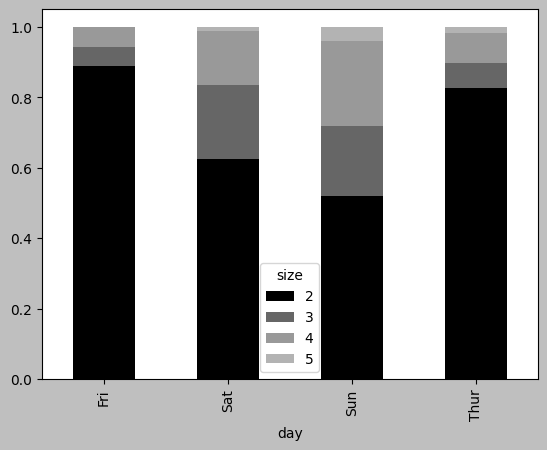

In [47]:
party_pcts.plot.bar(stacked=True)

从这个数据集中可以看出，周末时聚会的人数似乎会增多。

对于那些在绘制图表之前需要先进行汇总或统计的数据，使用 seaborn包可以大大简化处理过程（可以通过 `conda install seaborn` 来安装该包）。现在，让我们用 seaborn来查看每天的小费比例吧（生成的图表详见“带误差条的每日小费比例”部分）。

In [48]:
import seaborn as sns
tips['tip_pct'] = tips['tip'] / (tips['total_bill'] - tips['tip'])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


<Axes: xlabel='tip_pct', ylabel='day'>

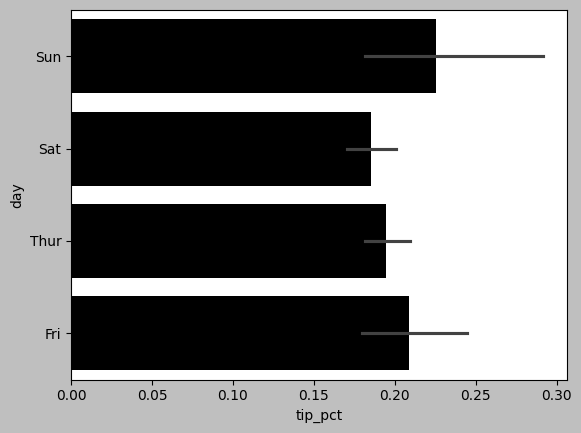

In [49]:
sns.barplot(x='tip_pct', y='day', data=tips, orient='h')

在 Seaborn 中绘制图表时，需要提供一个数据参数，该参数可以是 pandas DataFrame。其他参数用于指定列名。由于每天的每个数值都对应多个观测值，因此条形图表示的是“tip_pct”的平均值；而绘制在条形图上的黑色线条则代表 95% 的置信区间（这一设置可以通过可选参数进行调整）。

`seaborn.barplot`提供了一个`hue`选项，通过该选项我们可以根据另一个分类变量对数据进行分析（例如：按日期和时间段划分销售数据）。

<Axes: xlabel='tip_pct', ylabel='day'>

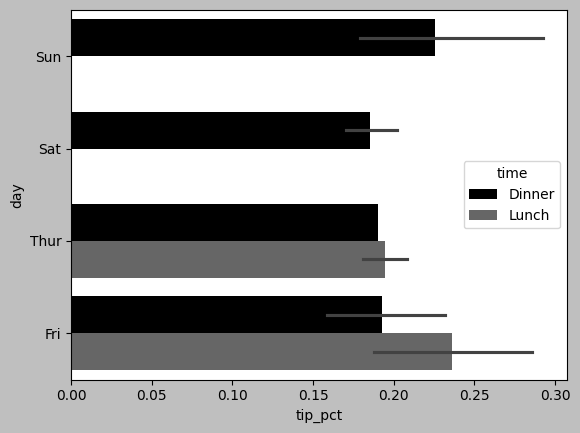

In [50]:
sns.barplot(x='tip_pct', y='day', data=tips, orient='h', hue='time')

请注意，seaborn已经自动更改了图表的外观设置，包括默认的颜色方案、图表背景以及网格线的颜色。你可以使用 `seaborn.set_style` 来切换不同的图表显示效果。

In [51]:
sns.set_style('whitegrid')

在为黑白印刷介质制作图表时，设置灰度色彩调色板会非常有用。具体设置方法如下：

In [52]:
sns.set_palette('Greys_r')

### 直方图与密度图

直方图是一种用于显示数据值出现频率的条形图。它将数据点分成若干个离散的、间距均匀的区间，然后绘制每个区间内的数据点数量。以之前的小费数据为例，我们可以使用 Series 对象的 plot.hist 方法来绘制小费金额占总账单金额的比例的直方图（详见“小费金额占比的直方图”部分）。

<Axes: ylabel='Frequency'>

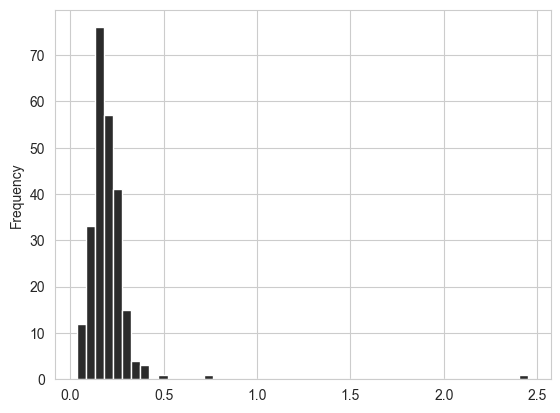

In [53]:
tips['tip_pct'].plot.hist(bins=50)

另一种相关的图表类型是密度图。它是通过计算生成观测数据所需的连续概率分布的估计值来制作的。通常的做法是将这种概率分布近似为多个“核函数”的组合，这些核函数都是较为简单的概率分布，例如正态分布。因此，密度图也被称为核密度估计图。使用 `plot.density` 可以生成基于传统正态分布混合模型得到的密度图（详见“小费比例的密度图”示例）。

<Axes: ylabel='Density'>

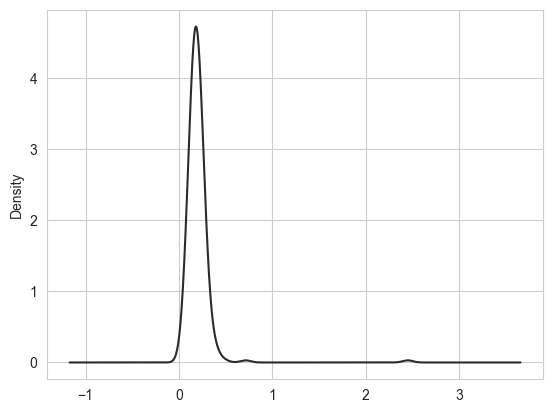

In [54]:
tips['tip_pct'].plot.density()

这种类型的脚本需要使用 SciPy，因此如果你还没有安装它，可以现在先暂停操作，然后去安装它。

`conda install scipy`

Seaborn通过其histplot方法使生成直方图和密度图变得更加简单。该方法可以同时绘制直方图和连续密度分布图。例如，考虑这样一个双峰分布：它是由两个不同的标准正态分布产生的数据构成的（详见“正态混合分布的标准化直方图”）。

<Axes: ylabel='Count'>

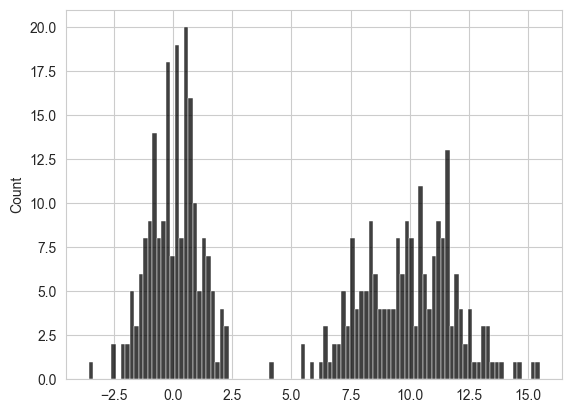

In [56]:
comp1 = np.random.standard_normal(200)
comp2 = np.random.standard_normal(200) * 2 + 10
values = pd.Series(np.concatenate([comp1, comp2]))
sns.histplot(values, bins=100, color='black')

### 散点图或点状图

点图或散点图是用来分析两个一维数据序列之间关系的有效工具。例如，我们在这里从 statsmodels 项目中加载了宏观数据集，选取了其中几个变量，然后计算了这些变量之间的对数差值。

In [57]:
macro = pd.read_csv('examples/macrodata.csv')
macro.head()

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959,1,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959,2,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959,3,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959,4,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960,1,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


In [58]:
data = macro[['cpi', 'm1', 'tbilrate', 'unemp']]
data

,cpi,m1,tbilrate,unemp
0,28.980,139.7,2.82,5.8
1,29.150,141.7,3.08,5.1
2,29.350,140.5,3.82,5.3
3,29.370,140.0,4.33,5.6
4,29.540,139.6,3.50,5.2
...,...,...,...,...
198,216.889,1474.7,1.17,6.0
199,212.174,1576.5,0.12,6.9
200,212.671,1592.8,0.22,8.1
201,214.469,1653.6,0.18,9.2


In [60]:
trans_data = np.log(data).diff().dropna()
trans_data

,cpi,m1,tbilrate,unemp
1,0.005849,0.014215,0.088193,-0.128617
2,0.006838,-0.008505,0.215321,0.038466
3,0.000681,-0.003565,0.125317,0.055060
4,0.005772,-0.002861,-0.212805,-0.074108
5,0.000338,0.004289,-0.266946,0.000000
...,...,...,...,...
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339


然后我们可以使用 seaborn 的 regplot 方法来绘制散点图，并在散点图上拟合一条线性回归线（详见“seaborn 的回归/散点图”相关内容）。

Text(0.5, 1.0, 'Changes in log(m1) versus log(unemp)')

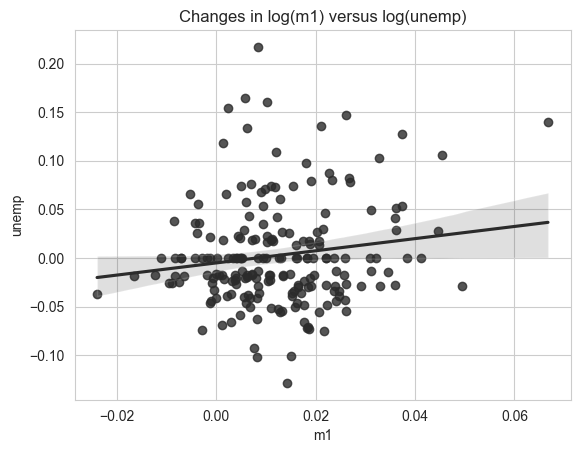

In [61]:
ax = sns.regplot(x='m1', y='unemp', data=trans_data)
ax.set_title('Changes in log(m1) versus log(unemp)')

在探索性数据分析中，能够查看一组变量之间的所有散点图是非常有用的；这种图表被称为“成对散点图”或“散点图矩阵”。从头开始绘制这样的图表需要花费不少时间，因此seaborn提供了一个非常方便的`pairplot`函数，该函数允许将每个变量的直方图或密度估计值显示在对角线上（具体效果可以参考statsmodels宏数据生成的散点图矩阵）。

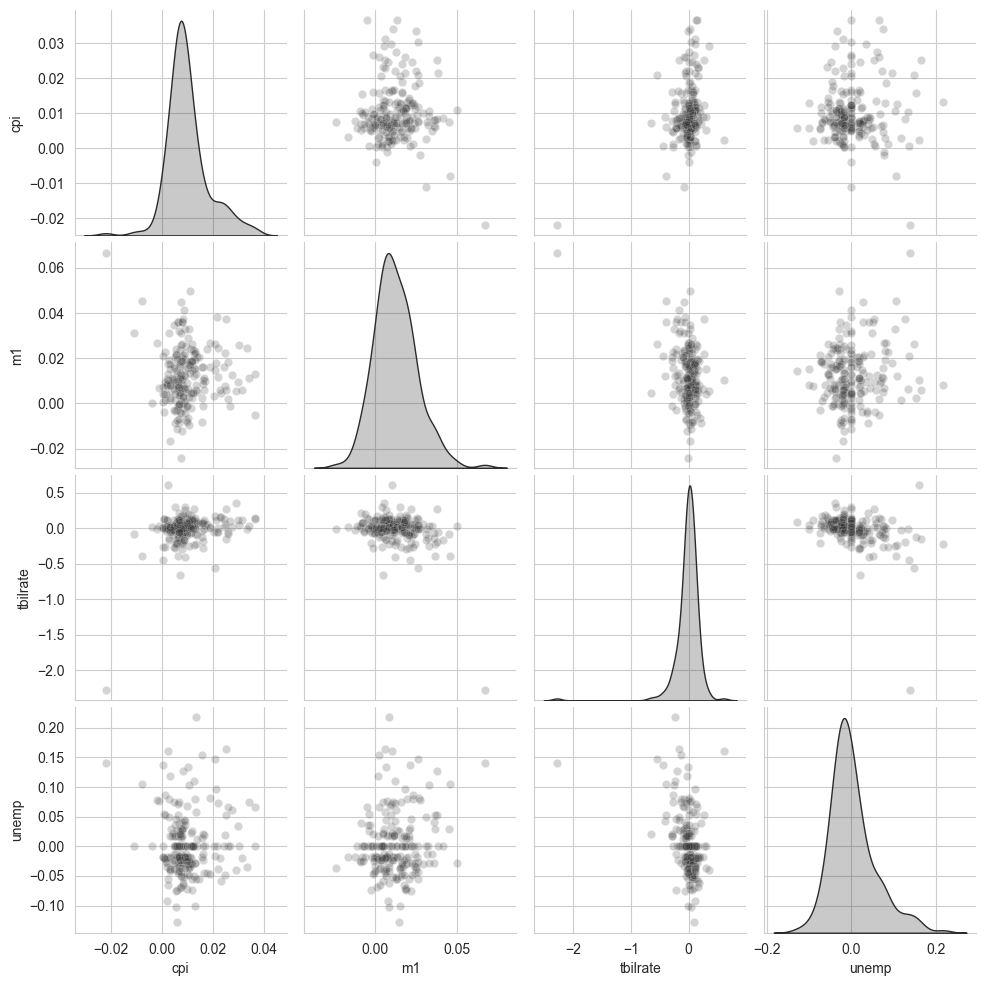

In [62]:
sns.pairplot(trans_data, diag_kind='kde', plot_kws={'alpha':0.2})

你可能会注意到 `plot_kws` 这个参数。它允许我们将配置选项传递给用于绘制非对角线元素的各个绘图函数。如需了解更多详细的配置选项，请查阅 seaborn.pairplot 的文档说明。

### 多面体网格与分类数据

那么，对于那些包含多个分类变量的数据集来说，该如何进行数据可视化呢？一种有效的方法是使用“面格图”：这种图表采用二维布局，根据某个变量的不同取值，将数据分配到各个子图中。Seaborn提供了一个名为`catplot`的内置函数，可以轻松地生成各种基于分类变量进行数据分组的面格图（例如，下图展示了按“日期/时间”以及“吸烟者身份”对数据进行的分类统计结果）。

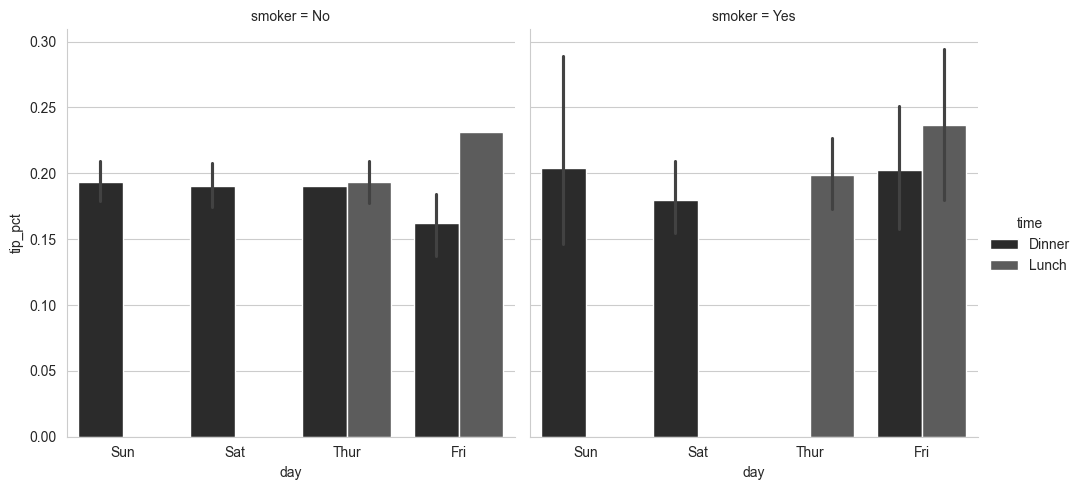

In [63]:
sns.catplot(x='day', y='tip_pct', hue='time', col='smoker', kind='bar', data=tips[tips.tip_pct < 1])

我们不必通过使用不同的条形颜色来按“时间”对数据进行分析；也可以通过为每个时间值添加一行来扩展数据网格的显示方式（例如：按时间及吸烟者分类的每日提成百分比）。

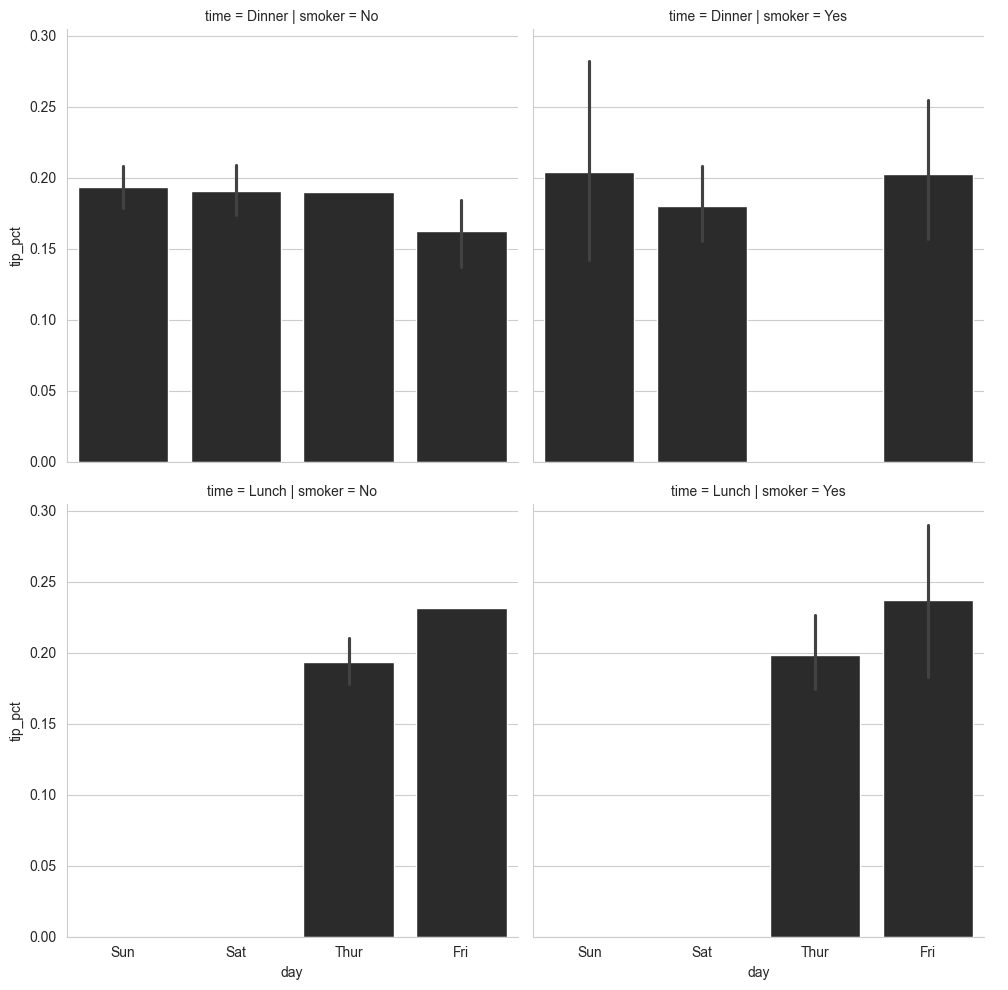

In [64]:
sns.catplot(x='day', y='tip_pct', row='time', col='smoker', kind='bar', data=tips[tips.tip_pct < 1])

`catplot`还支持其他类型的图表，根据您的需求，这些图表可能会非常有用。例如，箱形图可以有效地展示数据的中位数、四分位数以及异常值（详见“按日期划分的小费比例箱形图”）。

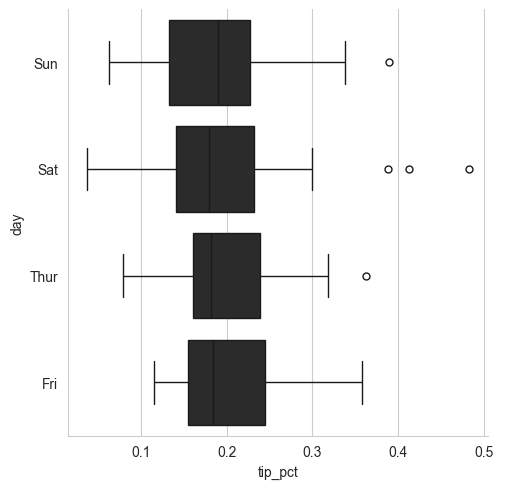

In [66]:
sns.catplot(x="tip_pct", y="day", kind="box", data=tips[tips.tip_pct < 0.5])

你可以使用更通用的seaborn.FacetGrid类来创建自己的面格图。更多相关信息请参阅seaborn的官方文档。

## 其他Python可视化工具

与开源软件通常的情况一样，使用Python创建图形的方法有很多种，多到无法一一列举。自2010年以来，人们投入了大量精力来开发可用于网页展示的交互式图形。借助Altair、Bokeh和Plotly等工具，现在可以使用Python制作出适用于网页浏览器的动态交互式图形了。

对于需要为印刷品或网站制作静态图形的情况，我建议使用matplotlib以及基于matplotlib开发的库，比如pandas和seaborn来满足您的需求。而对于其他数据可视化方面的需求，学习如何使用其他可用的工具可能会非常有用。我鼓励您继续探索这个不断发展与创新的工具生态系统。

关于数据可视化的优秀书籍是克劳斯·O·威尔克所著的《数据可视化基础》，该书有纸质版，也可以在克劳斯的网站 https://clauswilke.com/dataviz 上下载。